# 01 — Data Exploration: Research Universe V1

Khám phá snapshot market data đầu tiên của Sigma — dữ liệu **thật** được tải qua pipeline
(ADR-0001/0003): 12 assets, 2015 → 2026, checksum-verified.

Mục tiêu: nhìn dữ liệu bằng mắt để chuẩn bị cho hướng nghiên cứu **HMM regime layer**
(ADR-0007/0008) — tìm dấu hiệu volatility clustering, fat tails, và các giai đoạn thị trường khác nhau.

> Notebook này chỉ để **khám phá** — đo lường nghiêm túc nằm ở `tests/evaluation/`.
> Không phải source of truth (xem RULES).


## 1. Tải snapshot qua pipeline của Sigma

Dùng chính module `sigma.data.snapshot` — checksum được verify khi load.


In [ ]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sigma.data.snapshot import load_snapshot
from sigma.modeling import simple_returns

sns.set_theme(style="whitegrid", palette="muted")

# Locate the data dir robustly regardless of kernel cwd (repo root vs notebooks/)
_candidates = [
    Path("data/processed/prices"),
    Path("../../data/processed/prices"),
    Path(os.getcwd()) / "data" / "processed" / "prices",
]
for _cand in _candidates:
    snapshots = sorted(_cand.glob("research-universe-v1__*.parquet"))
    if snapshots:
        break
assert snapshots, "Không tìm thấy snapshot — chạy `make download` từ repo root trước!"
latest = snapshots[-1]

observations, meta = load_snapshot(latest)
print(f"snapshot : {latest.name}")
print(f"provider : {meta.provider} | rows: {meta.rows} | checksum: OK")

snapshot : research-universe-v1__20260824T092245Z.parquet
provider : yfinance | rows: 35112 | checksum: OK


## 2. Returns — ma trận aligned 12 assets

In [ ]:
matrix = simple_returns(observations)
returns = matrix.values
print(f"returns  : {returns.shape[0]} days x {returns.shape[1]} assets")
print(f"range    : {returns.index[0].date()} -> {returns.index[-1].date()}")
print(f"dataset  : {matrix.dataset_id}")
returns.describe().T

returns  : 2925 days x 12 assets
range    : 2015-01-05 -> 2026-08-21
dataset  : research-universe-v1__20260824T092245Z


,count,mean,std,min,25%,50%,75%,max
equity-aapl-us,2925.0,0.001036,0.018123,-0.128647,-0.007331,0.000988,0.009959,0.153289
equity-amzn-us,2925.0,0.001181,0.020868,-0.140494,-0.008930,0.001042,0.011626,0.153206
equity-googl-us,2925.0,0.001048,0.018338,-0.116341,-0.007882,0.001216,0.010040,0.162584
equity-jpm-us,2925.0,0.000839,0.016977,-0.149649,-0.007009,0.000766,0.008946,0.180125
equity-meta-us,2925.0,0.000956,0.023849,-0.263901,-0.009569,0.000951,0.012093,0.232824
equity-msft-us,2925.0,0.001006,0.017397,-0.147390,-0.007043,0.000904,0.009591,0.155067
equity-nvda-us,2925.0,0.002543,0.030337,-0.187558,-0.012544,0.002554,0.017636,0.298067
equity-xom-us,2925.0,0.000515,0.017323,-0.122248,-0.008184,0.000367,0.009257,0.126867
etf-gld-us,2925.0,0.000500,0.010191,-0.102742,-0.004759,0.000569,0.005598,0.063587
etf-qqq-us,2925.0,0.000787,0.013828,-0.119788,-0.005106,0.001221,0.007868,0.120031


## 3. Giá chuẩn hóa — nhìn 12 assets chung một chart

Normalize về 100 tại ngày đầu để so sánh quỹ đạo dài hạn.


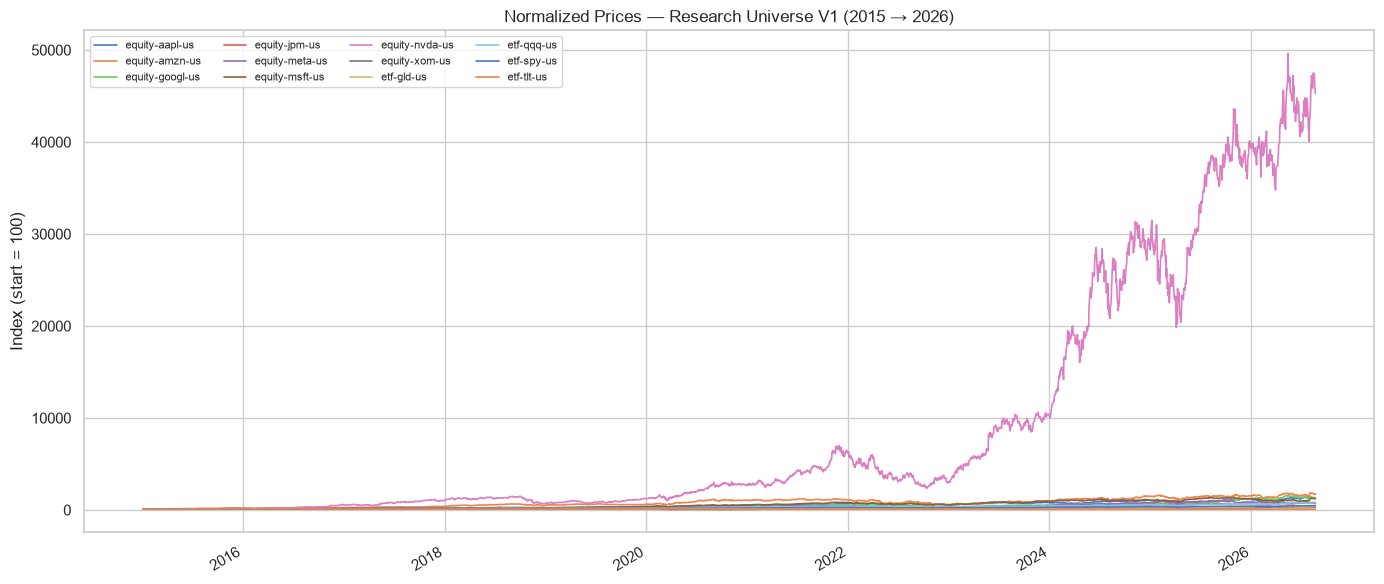

In [ ]:
prices = (1 + returns).cumprod()
normalized = prices / prices.iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 6))
normalized.plot(ax=ax, linewidth=1.2)
ax.set_title("Normalized Prices — Research Universe V1 (2015 → 2026)")
ax.set_ylabel("Index (start = 100)")
ax.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

## 4. Returns — volatility clustering nhìn bằng mắt

Các giai đoạn 2020 (COVID) và 2022 (bear market) thể hiện rõ biến động cụm lại.


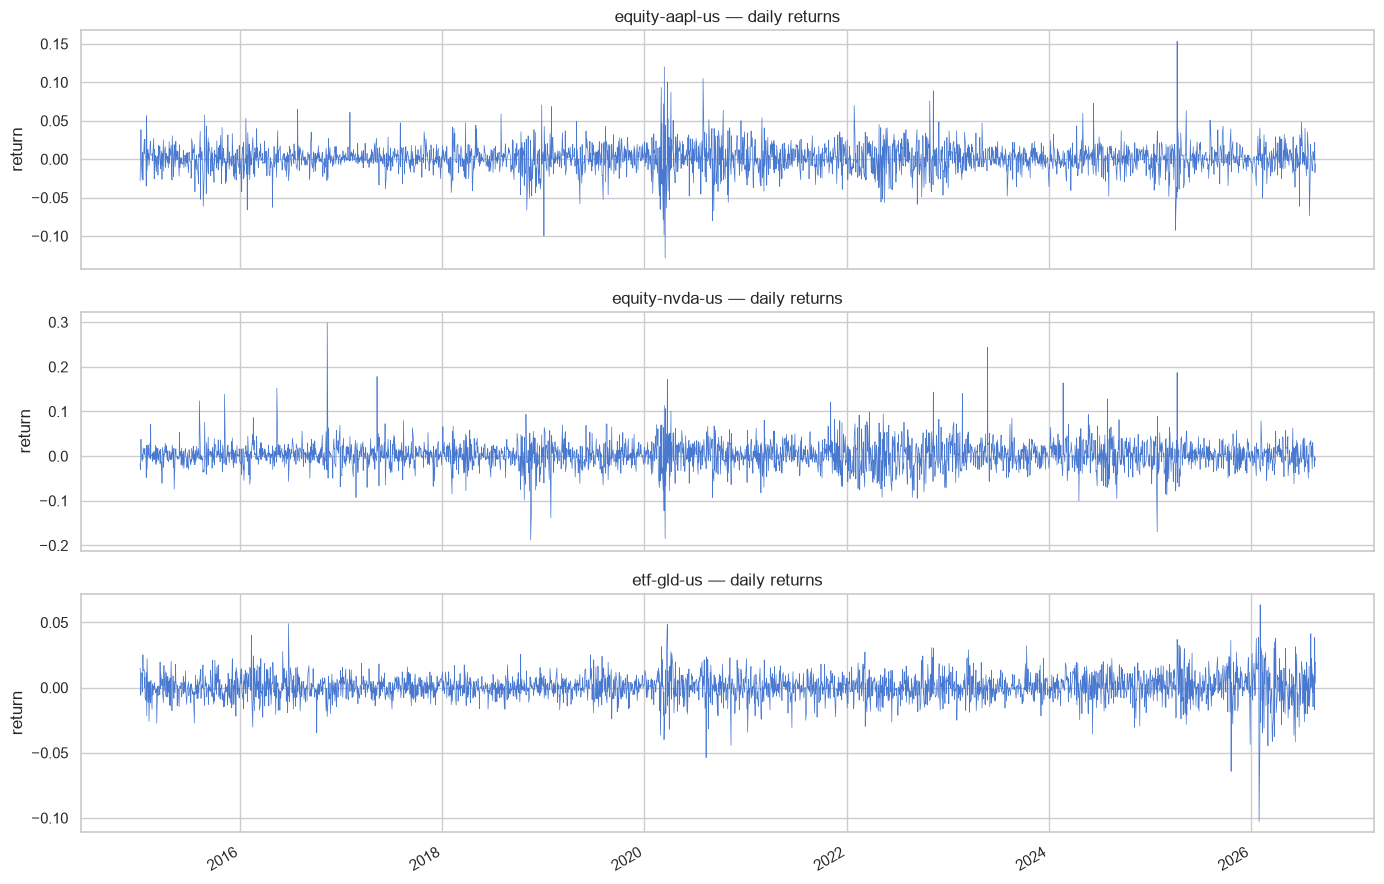

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, asset in zip(axes, ["equity-aapl-us", "equity-nvda-us", "etf-gld-us"]):
    returns[asset].plot(ax=ax, linewidth=0.5)
    ax.set_title(f"{asset} — daily returns")
    ax.set_ylabel("return")
plt.tight_layout()
plt.show()

## 5. Phân phối returns vs Normal — fat tails

So sánh histogram với đường chuẩn Normal cùng mean/std.


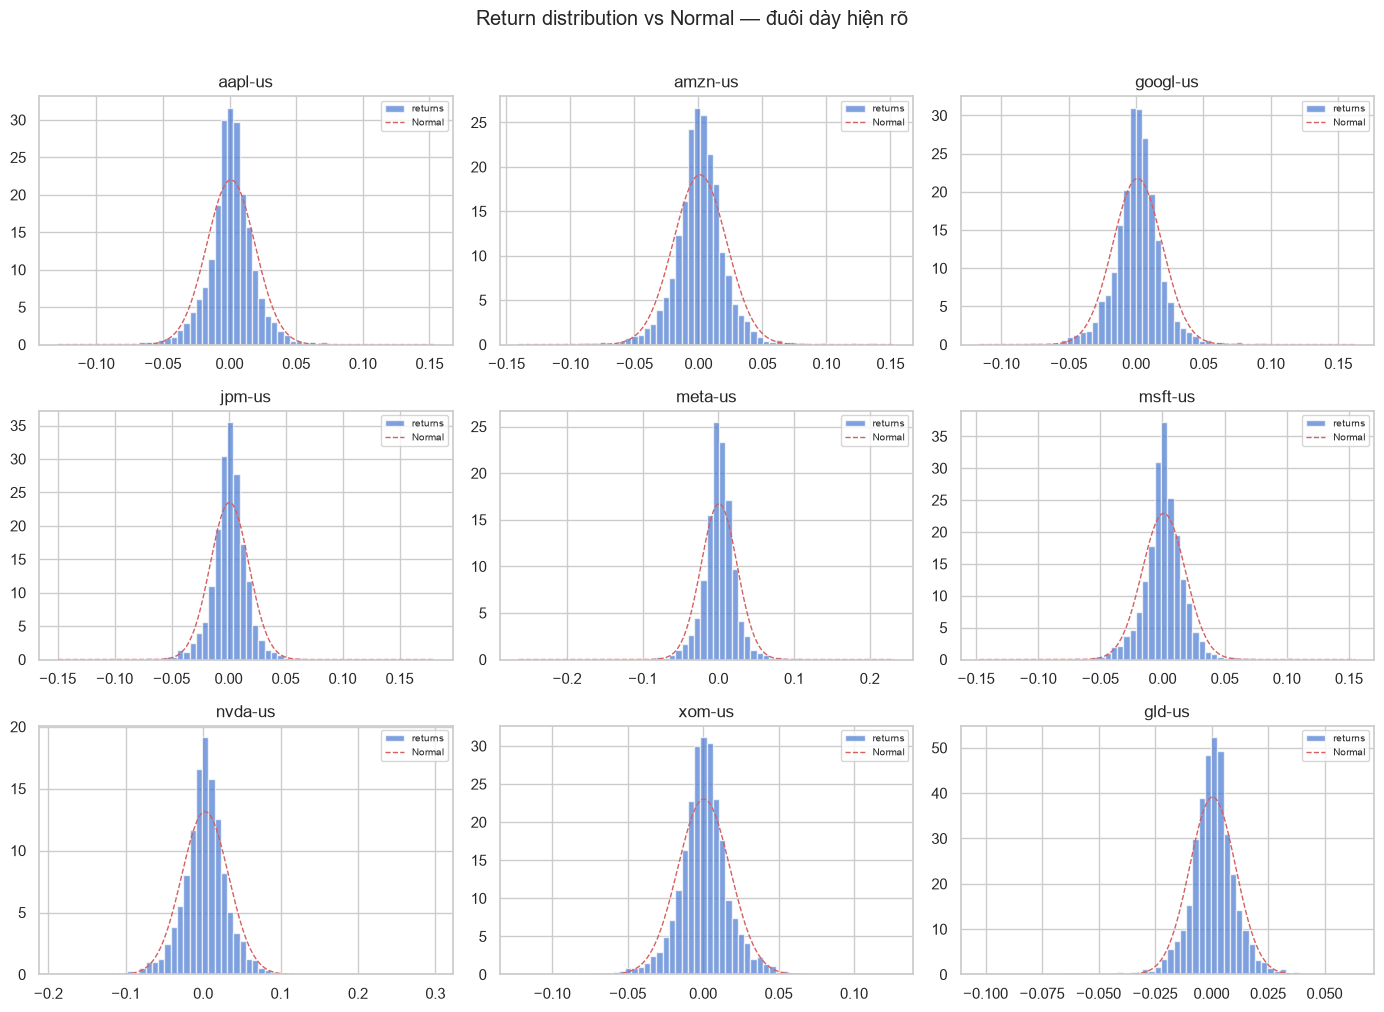

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
assets = list(returns.columns)[:9]
for ax, asset in zip(axes.flat, assets):
    r = returns[asset].dropna()
    ax.hist(r, bins=60, density=True, alpha=0.7, label="returns")
    x = np.linspace(r.min(), r.max(), 200)
    normal = (1 / (r.std() * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - r.mean()) / r.std()) ** 2)
    ax.plot(x, normal, "r--", linewidth=1, label="Normal")
    ax.set_title(asset.replace("equity-", "").replace("etf-", ""))
    ax.legend(fontsize=7)
plt.suptitle("Return distribution vs Normal — đuôi dày hiện rõ", y=1.01)
plt.tight_layout()
plt.show()

## 6. Correlation matrix — cấu trúc đa dạng của universe

Equities tương quan cao (SPY/QQQ/tech), còn GLD/TLT đứng tách biệt — tài sản phòng thủ.


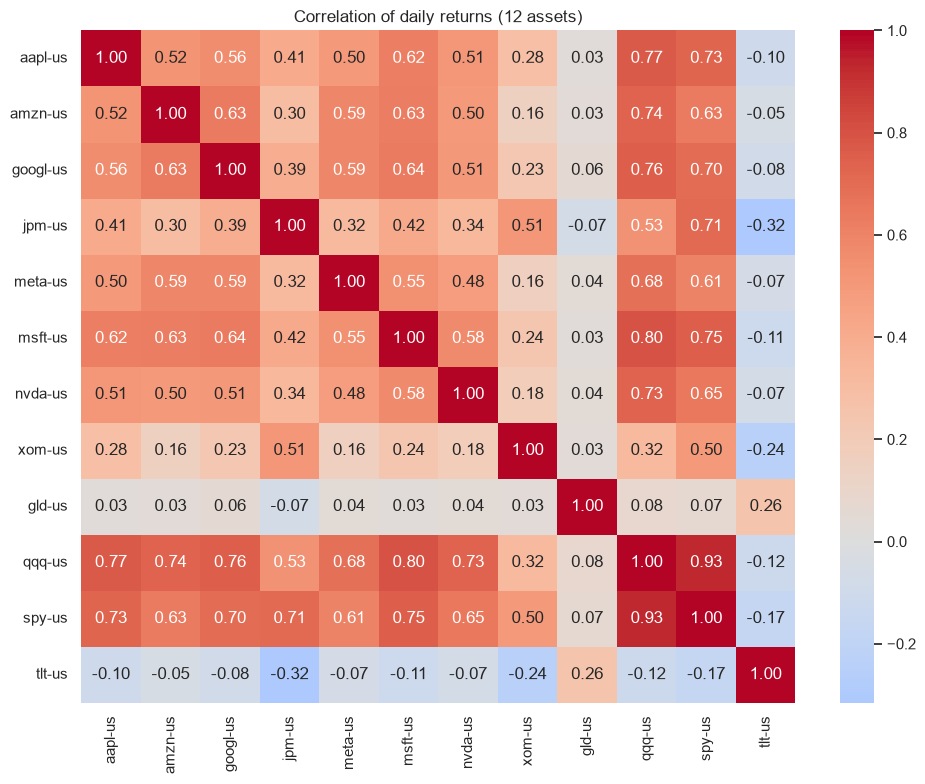

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = returns.corr()
short = corr.columns.str.replace("equity-", "").str.replace("etf-", "")
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            xticklabels=short, yticklabels=short, ax=ax)
ax.set_title("Correlation of daily returns (12 assets)")
plt.tight_layout()
plt.show()

## 7. Volatility qua thời gian — rolling 60d

Nhìn biến động "sống động" theo thời gian: 2020, 2022 nổi bật; gần đây NVDA rất bạo.


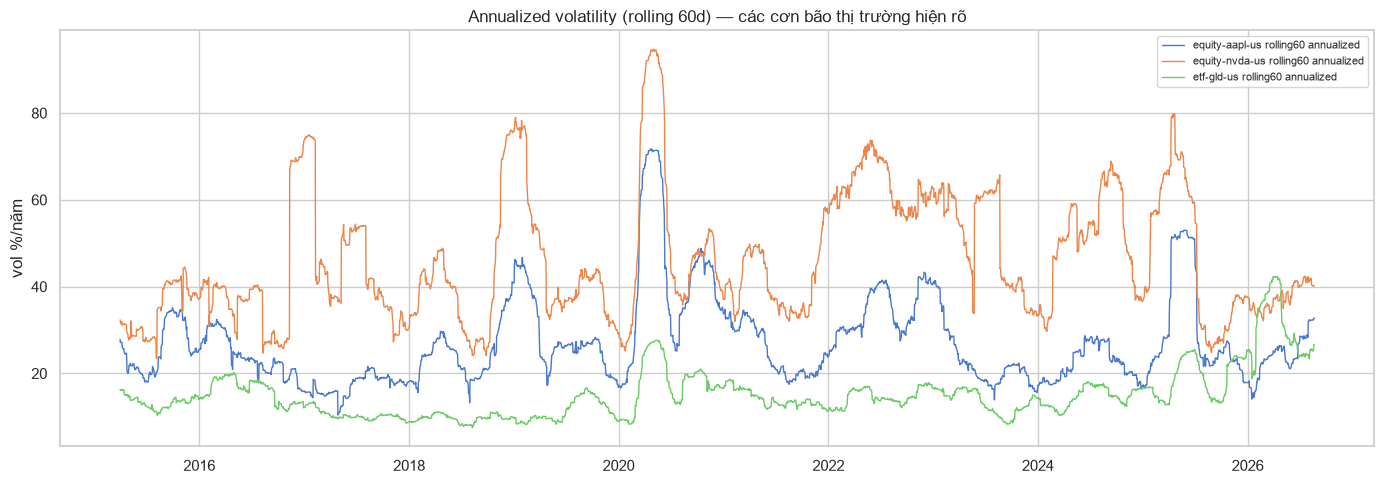

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
for asset in ["equity-aapl-us", "equity-nvda-us", "etf-gld-us"]:
    series = returns[asset]
    window_vol = series.rolling(60).std().dropna() * np.sqrt(252) * 100
    ax.plot(window_vol.index, window_vol, linewidth=1, label=f"{asset} rolling60 annualized")
ax.set_title("Annualized volatility (rolling 60d) — các cơn bão thị trường hiện rõ")
ax.set_ylabel("vol %/năm")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 8. Quan sát ban đầu cho hướng regime (HMM)

- **Volatility clustering** rõ rệt: các giai đoạn bão cụm lại (2020, 2022) — conditional vol có đất sống.
- **Fat tails** thấy được ở histogram — câu hỏi mở: sau khi tách regime, mỗi regime còn fat tails không?
- **Cấu trúc tương quan đa dạng**: equities vs GLD/TLT — portfolio diversification thật sự.
- Các giai đoạn 2015→2018 (yên ắng tương đối), 2020 (sốc), 2022 (bear), 2023→2026 (bull/AI) —
  **ứng viên tự nhiên cho Calm / Volatile / Crisis**.

Những quan sát này là động lực cho WP-4b (HMM regime layer) — nhưng mọi kết luận đo lường
sẽ đến từ `tests/evaluation/`, không từ notebook này.
